# CISC7204 Assignment 01

**Submitted by:** Xiji Hang (MC646933).

## Module 03 · Lab 01 — Exploring automobile prices

**Collaborators:** Xiji Hang (MC646933) and Xiaoyu Guo (MC648131).  
**Contribution:** All laboratory work is completed jointly.

**Source:** Adapted from the supplied IBM / Skills Network teaching notebook; original author credits are retained below. The source template is preserved separately.

**Execution:** Local Anaconda / Jupyter; results in this working copy are generated by executing its code. Input: `automobileEDA.csv`, the unchanged dataset snapshot specified by this lab.

**Dataset source:** [automobileEDA.csv](https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DA0101EN-SkillsNetwork/labs/Data%20files/automobileEDA.csv) (snapshot accessed 15 September 2026). Each row describes one automobile configuration with its specifications and listed price.

# Exploratory Data Analysis



    

## Objectives

After completing this lab you will be able to:

* Explore features or characteristics to predict price of car
* Analyze patterns and run descriptive statistical analysis
* Group data based on identified parameters and create pivot tables
* Identify the effect of independent attributes on price of cars

<h2>Table of Contents</h2>

<div class="alert alert-block alert-info" style="margin-top: 20px">
<ol>
    <li><a href="#import_data">Import Data from Module</a></li>
    <li><a href="#pattern_visualization">Analyzing Individual Feature Patterns using Visualization</a></li>
    <li><a href="#discriptive_statistics">Descriptive Statistical Analysis</a></li>
    <li><a href="#basic_grouping">Basics of Grouping</a></li>
    <li><a href="#correlation_causation">Correlation and Causation</a></li>
</ol>

</div>
 
<hr>

<h3>What are the main characteristics that have the most impact on the car price?</h3>

<h2 id='import_data'>1. Import the supplied EDA snapshot</h2>

The template specifies `automobileEDA.csv`. This snapshot keeps highway mpg and is loaded independently of Module 02's export, which renamed that field after conversion.

<h4>Setup</h4>

Import libraries:

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
from IPython.display import display, Markdown
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 40)
pd.set_option('display.precision', 4)
def locate_dataset(filename):
    # Accept a flat submission, the bundle root, or the notebooks subfolder.
    folders = (Path.cwd(), Path.cwd() / 'datasets' / 'raw',
               Path.cwd().parent / 'datasets' / 'raw')
    for folder in folders:
        candidate = folder / filename
        if candidate.is_file():
            return candidate.resolve()
    searched = ', '.join(str(folder / filename) for folder in folders)
    raise FileNotFoundError(f'Missing required dataset {filename}. Searched: {searched}')

def output_root_for(data_file):
    folder = data_file.resolve().parent
    if folder.name == 'raw' and folder.parent.name == 'datasets':
        return folder.parent.parent
    return folder

DATA_FILE = locate_dataset('automobileEDA.csv')
DATA = DATA_FILE.parent
OUTPUT_ROOT = output_root_for(DATA_FILE)
print(f'Python {sys.version.split()[0]} | pandas {pd.__version__} | NumPy {np.__version__}')

Python 3.14.6 | pandas 3.0.3 | NumPy 2.4.6


Load the data and store it in dataframe `df`:

In [2]:
path = DATA / 'automobileEDA.csv'
df = pd.read_csv(path)
print(f'Supplied EDA snapshot: {len(df)} rows × {df.shape[1]} columns.')
assert df['price'].notna().all()
df.head()

Supplied EDA snapshot: 201 rows × 29 columns.


,symboling,normalized-losses,make,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,horsepower-binned,diesel,gas
0,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.8111,0.8903,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0,11.1905,Medium,0,1
1,3,122,alfa-romero,std,two,convertible,rwd,front,88.6,0.8111,0.8903,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0,11.1905,Medium,0,1
2,1,122,alfa-romero,std,two,hatchback,rwd,front,94.5,0.8227,0.9097,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0,12.3684,Medium,0,1
3,2,164,audi,std,four,sedan,fwd,front,99.8,0.8486,0.9194,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0,9.7917,Medium,0,1
4,2,164,audi,std,four,sedan,4wd,front,99.4,0.8486,0.9222,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0,13.0556,Medium,0,1


<h2 id="pattern_visualization">2. Analyzing Individual Feature Patterns Using Visualization</h2>

Import visualization packages "Matplotlib" and "Seaborn". Don't forget about "%matplotlib inline" to plot in a Jupyter notebook.

In [3]:
# Figures use 300 DPI for readable high-resolution exports.
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
%matplotlib inline
sns.set_theme(style='whitegrid', context='notebook', font_scale=1.0)
plt.rcParams.update({'figure.figsize': (7.2, 4.2), 'figure.dpi': 300, 'axes.spines.top': False, 'axes.spines.right': False})

<h4>How to choose the right visualization method?</h4>
<p>When visualizing individual variables, it is important to first understand what type of variable you are dealing with. This will help us find the right visualization method for that variable.</p>

In [4]:
df.dtypes.rename('dtype').to_frame()

,dtype
symboling,int64
normalized-losses,int64
make,str
aspiration,str
num-of-doors,str
body-style,str
drive-wheels,str
engine-location,str
wheel-base,float64
length,float64


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3>Question  #1:</h3>

<b>What is the data type of the column "peak-rpm"? </b>
</div>

In [5]:
print('peak-rpm dtype:', df['peak-rpm'].dtype)

peak-rpm dtype: float64


For example, we can calculate the correlation between variables  of type "int64" or "float64" using the method "corr":

In [6]:
df.select_dtypes(include='number').corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.0000,0.4663,-0.5360,-0.3654,-0.2424,-0.5502,-0.2331,-0.1106,-0.1400,-0.0082,-0.1822,0.0758,0.2797,-0.0355,0.0362,-0.0824,0.0662,-0.1967,0.1967
normalized-losses,0.4663,1.0000,-0.0567,0.0194,0.0868,-0.3737,0.0994,0.1124,-0.0299,0.0556,-0.1147,0.2173,0.2395,-0.2250,-0.1819,0.1340,0.2386,-0.1015,0.1015
wheel-base,-0.5360,-0.0567,1.0000,0.8760,0.8145,0.5907,0.7821,0.5720,0.4932,0.1585,0.2503,0.3711,-0.3603,-0.4706,-0.5433,0.5846,0.4762,0.3072,-0.3072
length,-0.3654,0.0194,0.8760,1.0000,0.8572,0.4921,0.8807,0.6850,0.6090,0.1241,0.1597,0.5798,-0.2860,-0.6652,-0.6981,0.6906,0.6574,0.2112,-0.2112
width,-0.2424,0.0868,0.8145,0.8572,1.0000,0.3060,0.8662,0.7294,0.5449,0.1888,0.1899,0.6151,-0.2458,-0.6335,-0.6806,0.7513,0.6734,0.2444,-0.2444
height,-0.5502,-0.3737,0.5907,0.4921,0.3060,1.0000,0.3076,0.0747,0.1804,-0.0627,0.2597,-0.0870,-0.3100,-0.0498,-0.1048,0.1355,0.0038,0.2816,-0.2816
curb-weight,-0.2331,0.0994,0.7821,0.8807,0.8662,0.3076,1.0000,0.8491,0.6441,0.1676,0.1564,0.7580,-0.2794,-0.7495,-0.7949,0.8344,0.7854,0.2210,-0.2210
engine-size,-0.1106,0.1124,0.5720,0.6850,0.7294,0.0747,0.8491,1.0000,0.5726,0.2095,0.0289,0.8227,-0.2567,-0.6505,-0.6796,0.8723,0.7451,0.0708,-0.0708
bore,-0.1400,-0.0299,0.4932,0.6090,0.5449,0.1804,0.6441,0.5726,1.0000,-0.0554,0.0013,0.5669,-0.2674,-0.5820,-0.5913,0.5432,0.5546,0.0545,-0.0545
stroke,-0.0082,0.0556,0.1585,0.1241,0.1888,-0.0627,0.1676,0.2095,-0.0554,1.0000,0.1879,0.0985,-0.0657,-0.0347,-0.0352,0.0823,0.0373,0.2413,-0.2413


Self-correlation is 1 for nonconstant numerical columns. It is undefined for a constant column. The off-diagonal entries describe pairwise linear association.

<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h3> Question  #2: </h3>

<p>Find the correlation between the following columns: bore, stroke, compression-ratio, and horsepower.</p>
<p>Hint: if you would like to select those columns, use the following syntax: df[['bore','stroke','compression-ratio','horsepower']]</p>
</div>

In [7]:
df[['bore', 'stroke', 'compression-ratio', 'horsepower']].corr()

,bore,stroke,compression-ratio,horsepower
bore,1.0000,-0.0554,0.0013,0.5669
stroke,-0.0554,1.0000,0.1879,0.0985
compression-ratio,0.0013,0.1879,1.0000,-0.2145
horsepower,0.5669,0.0985,-0.2145,1.0000


Bore and horsepower are more positively associated than stroke and horsepower in this sample. Correlated engine measurements may provide overlapping information in later regression.

<h2>Continuous Numerical Variables:</h2> 

<p>Continuous numerical variables are variables that may contain any value within some range. They can be of type "int64" or "float64". A great way to visualize these variables is by using scatterplots with fitted lines.</p>

<p>In order to start understanding the (linear) relationship between an individual variable and the price, we can use "regplot" which plots the scatterplot plus the fitted regression line for the data. This will be useful later on for visualizing the fit of the simple linear regression model as well. </p>

Let's see several examples of different linear relationships:

<h3>Positive Linear Relationship</h4>

Let's find the scatterplot of "engine-size" and "price".

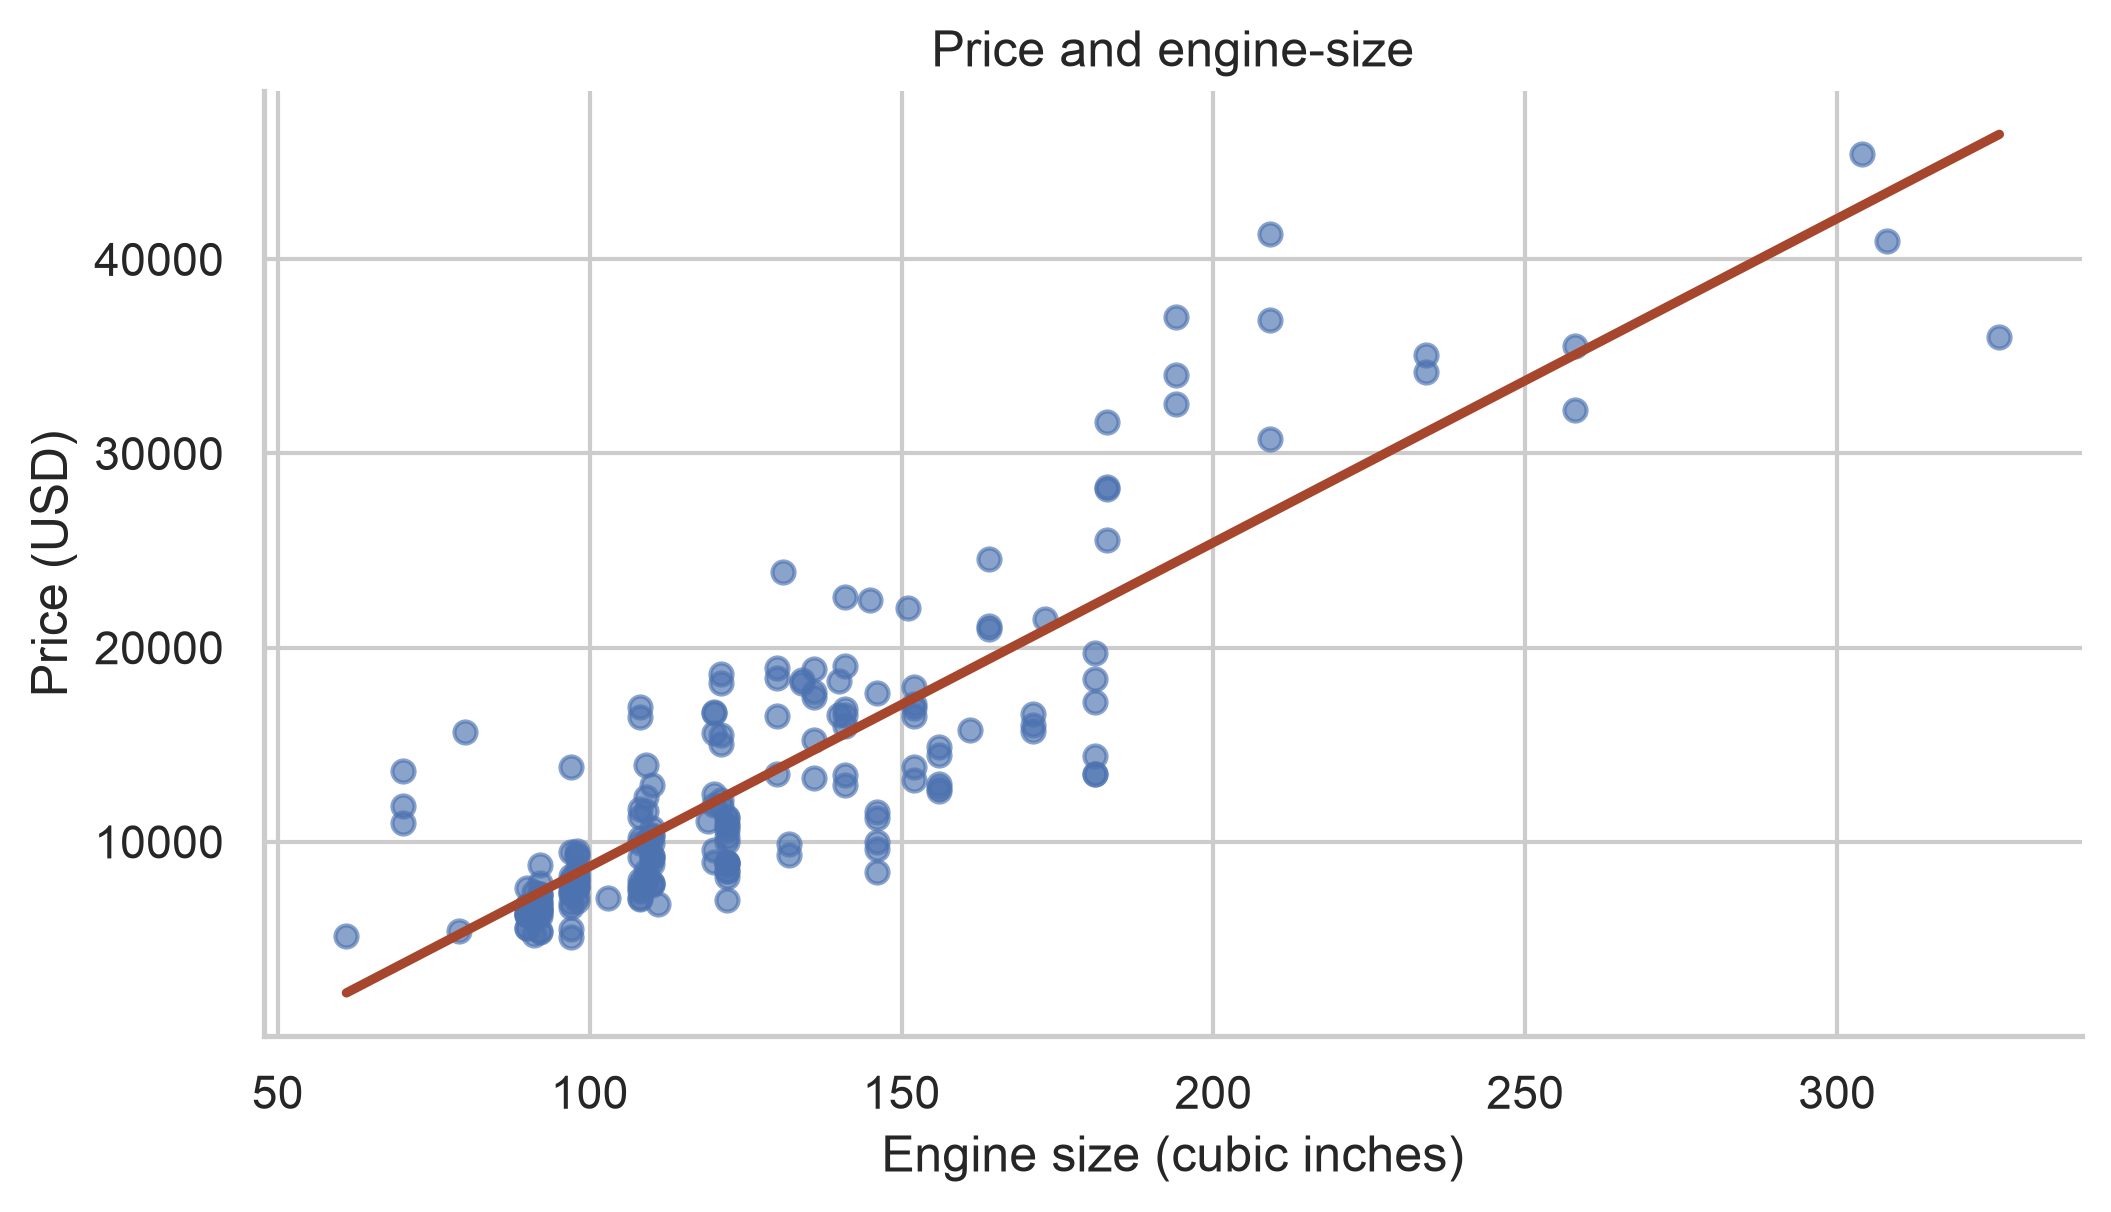

In [8]:
fig, ax = plt.subplots()
sns.regplot(data=df, x='engine-size', y='price', ci=None,
            scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#a6462d'}, ax=ax)
ax.set(title='Price and engine-size', xlabel='Engine size (cubic inches)', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

Engine size and price have a clear positive association in this sample. The evidence is the concentration of observations around the increasing trend; the angle of a line on a plot depends on axis scaling and does not measure predictive quality.

Calculate the coefficient rather than infer its size from the line's angle.

In [9]:
df[["engine-size", "price"]].corr()

,engine-size,price
engine-size,1.0000,0.8723
price,0.8723,1.0000


Highway mpg is a potential predictor variable of price. Let's find the scatterplot of "highway-mpg" and "price".

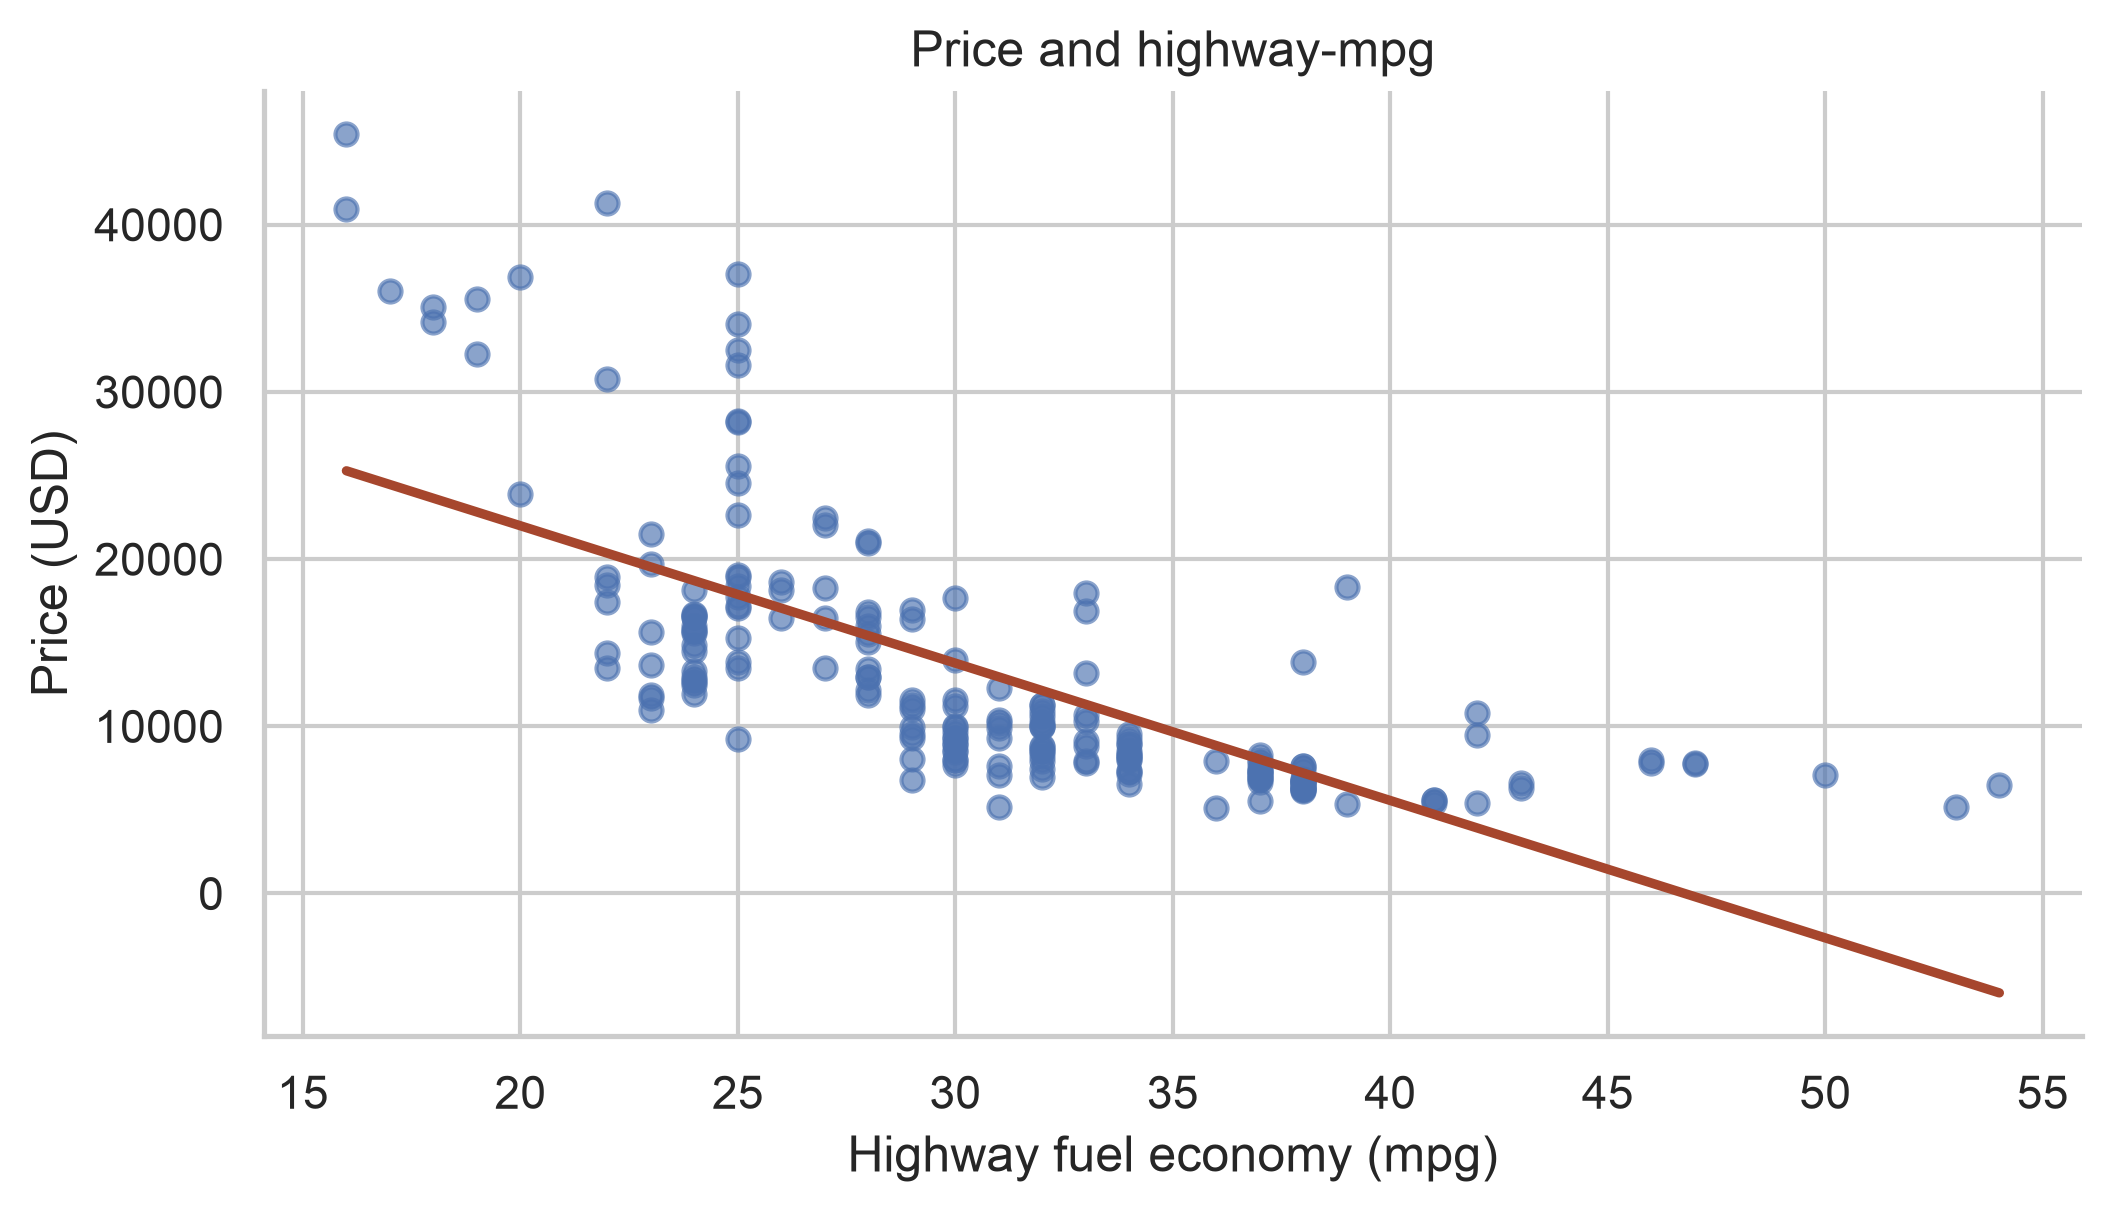

In [10]:
fig, ax = plt.subplots()
sns.regplot(data=df, x='highway-mpg', y='price', ci=None,
            scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#a6462d'}, ax=ax)
ax.set(title='Price and highway-mpg', xlabel='Highway fuel economy (mpg)', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

<p>As highway-mpg goes up, the price goes down: this indicates an inverse/negative relationship between these two variables. Highway mpg could potentially be a predictor of price.</p>

Quantify the negative linear association below.

In [11]:
df[['highway-mpg', 'price']].corr()

,highway-mpg,price
highway-mpg,1.0000,-0.7047
price,-0.7047,1.0000


<h3>Weak Linear Relationship</h3>

Let's see if "peak-rpm" is a predictor variable of "price".

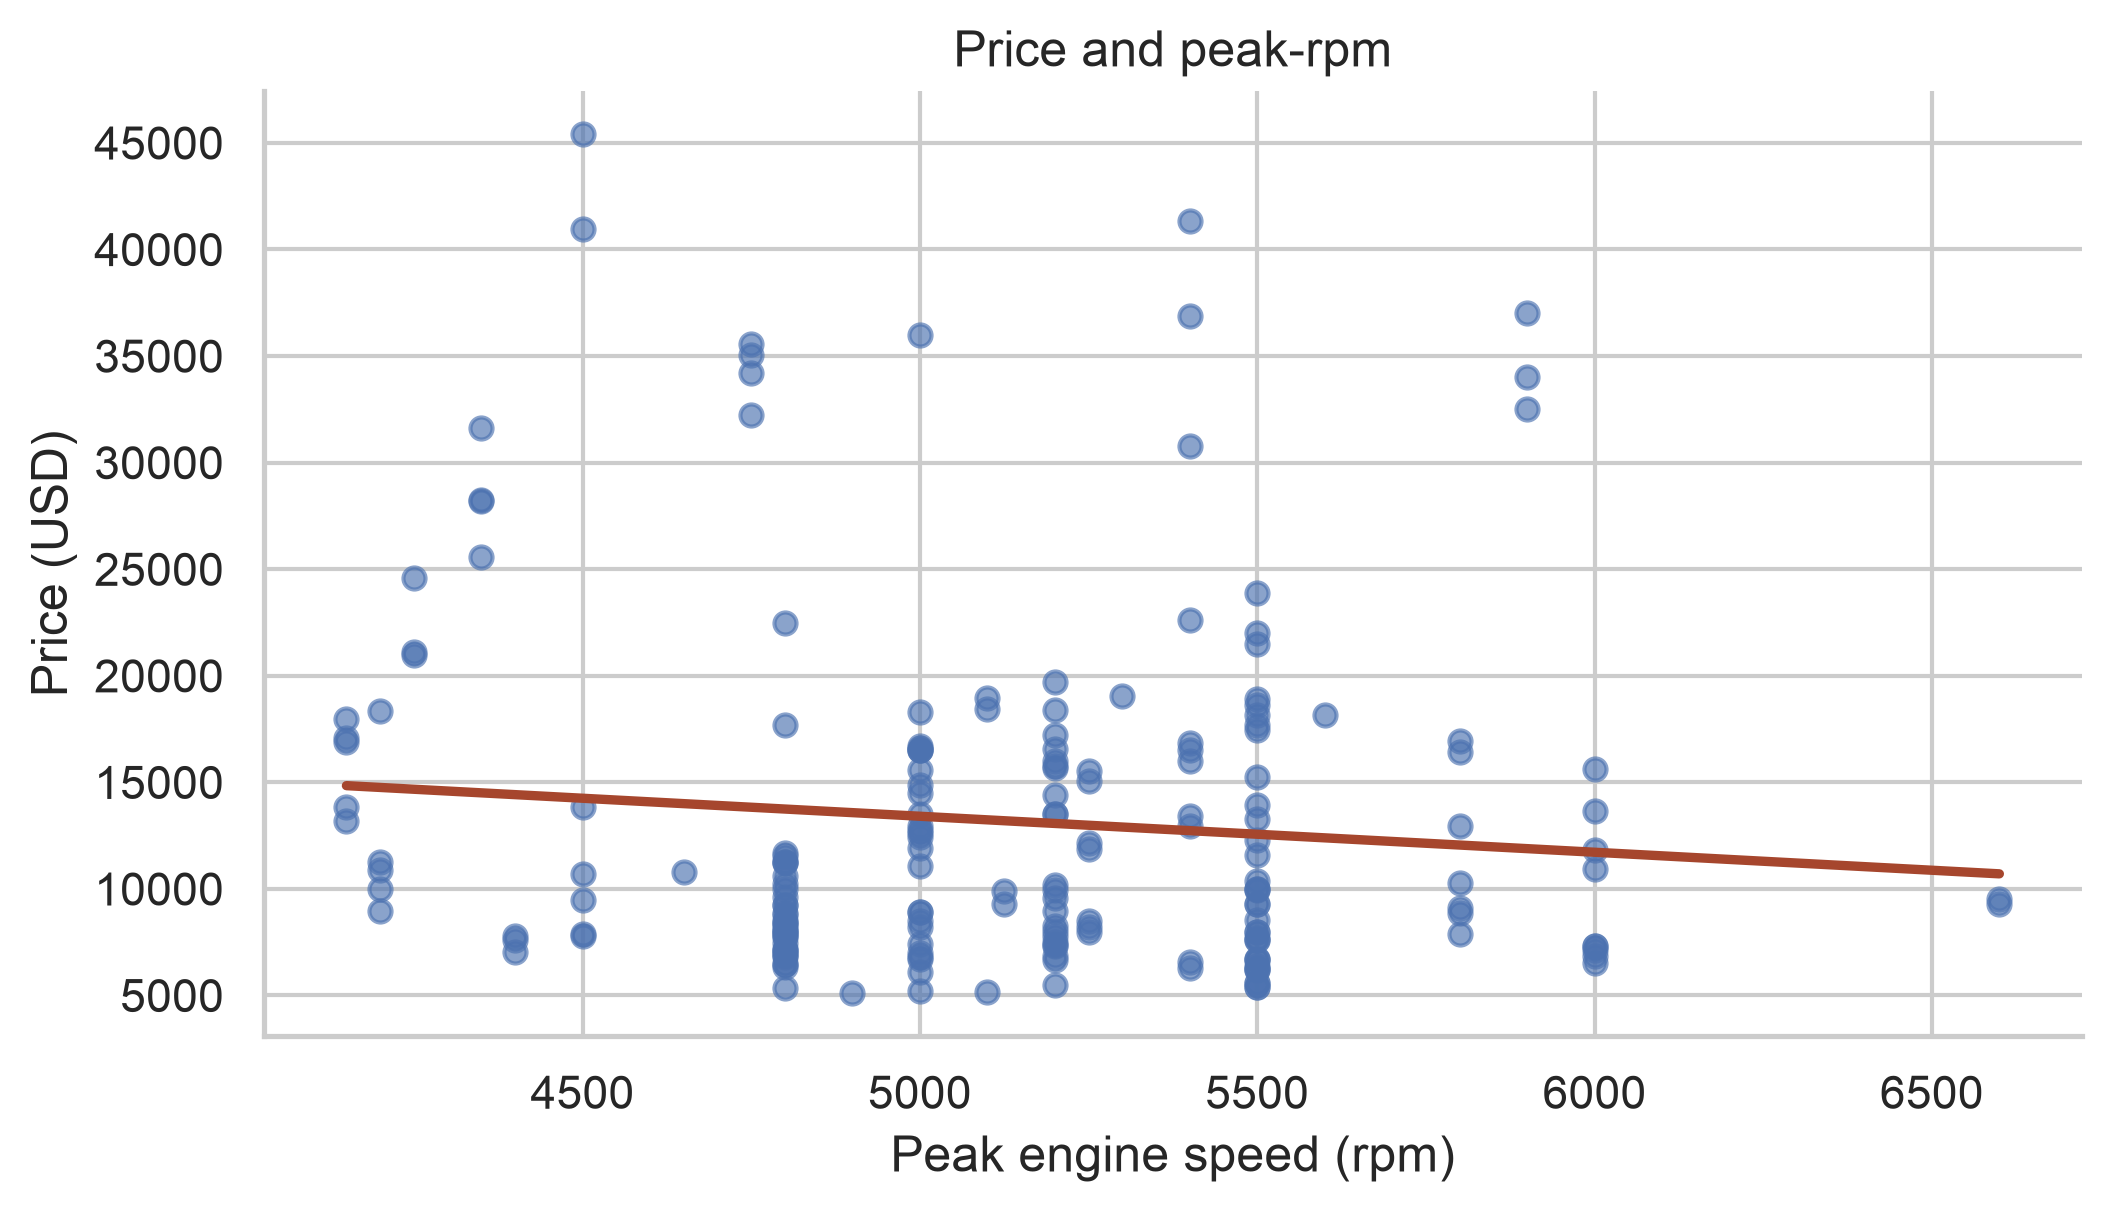

In [12]:
fig, ax = plt.subplots()
sns.regplot(data=df, x='peak-rpm', y='price', ci=None,
            scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#a6462d'}, ax=ax)
ax.set(title='Price and peak-rpm', xlabel='Peak engine speed (rpm)', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

Peak rpm has little marginal linear association with price. This does not rule out a nonlinear pattern or additional information conditional on other features.

The calculated coefficient below is close to zero.

In [13]:
df[['peak-rpm','price']].corr()

,peak-rpm,price
peak-rpm,1.0000,-0.1016
price,-0.1016,1.0000


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1> Question  3 a): </h1>

<p>Find the correlation  between x="stroke" and y="price".</p>
<p>Hint: if you would like to select those columns, use the following syntax: df[["stroke","price"]].  </p>
</div>

In [14]:
df[['stroke', 'price']].corr()

,stroke,price
stroke,1.0000,0.0823
price,0.0823,1.0000


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question  3 b):</h1>

<p>Given the correlation results between "price" and "stroke", do you expect a linear relationship?</p> 
<p>Verify your results using the function "regplot()".</p>
</div>

Stroke–price Pearson r = 0.0823; little marginal linear association is expected.


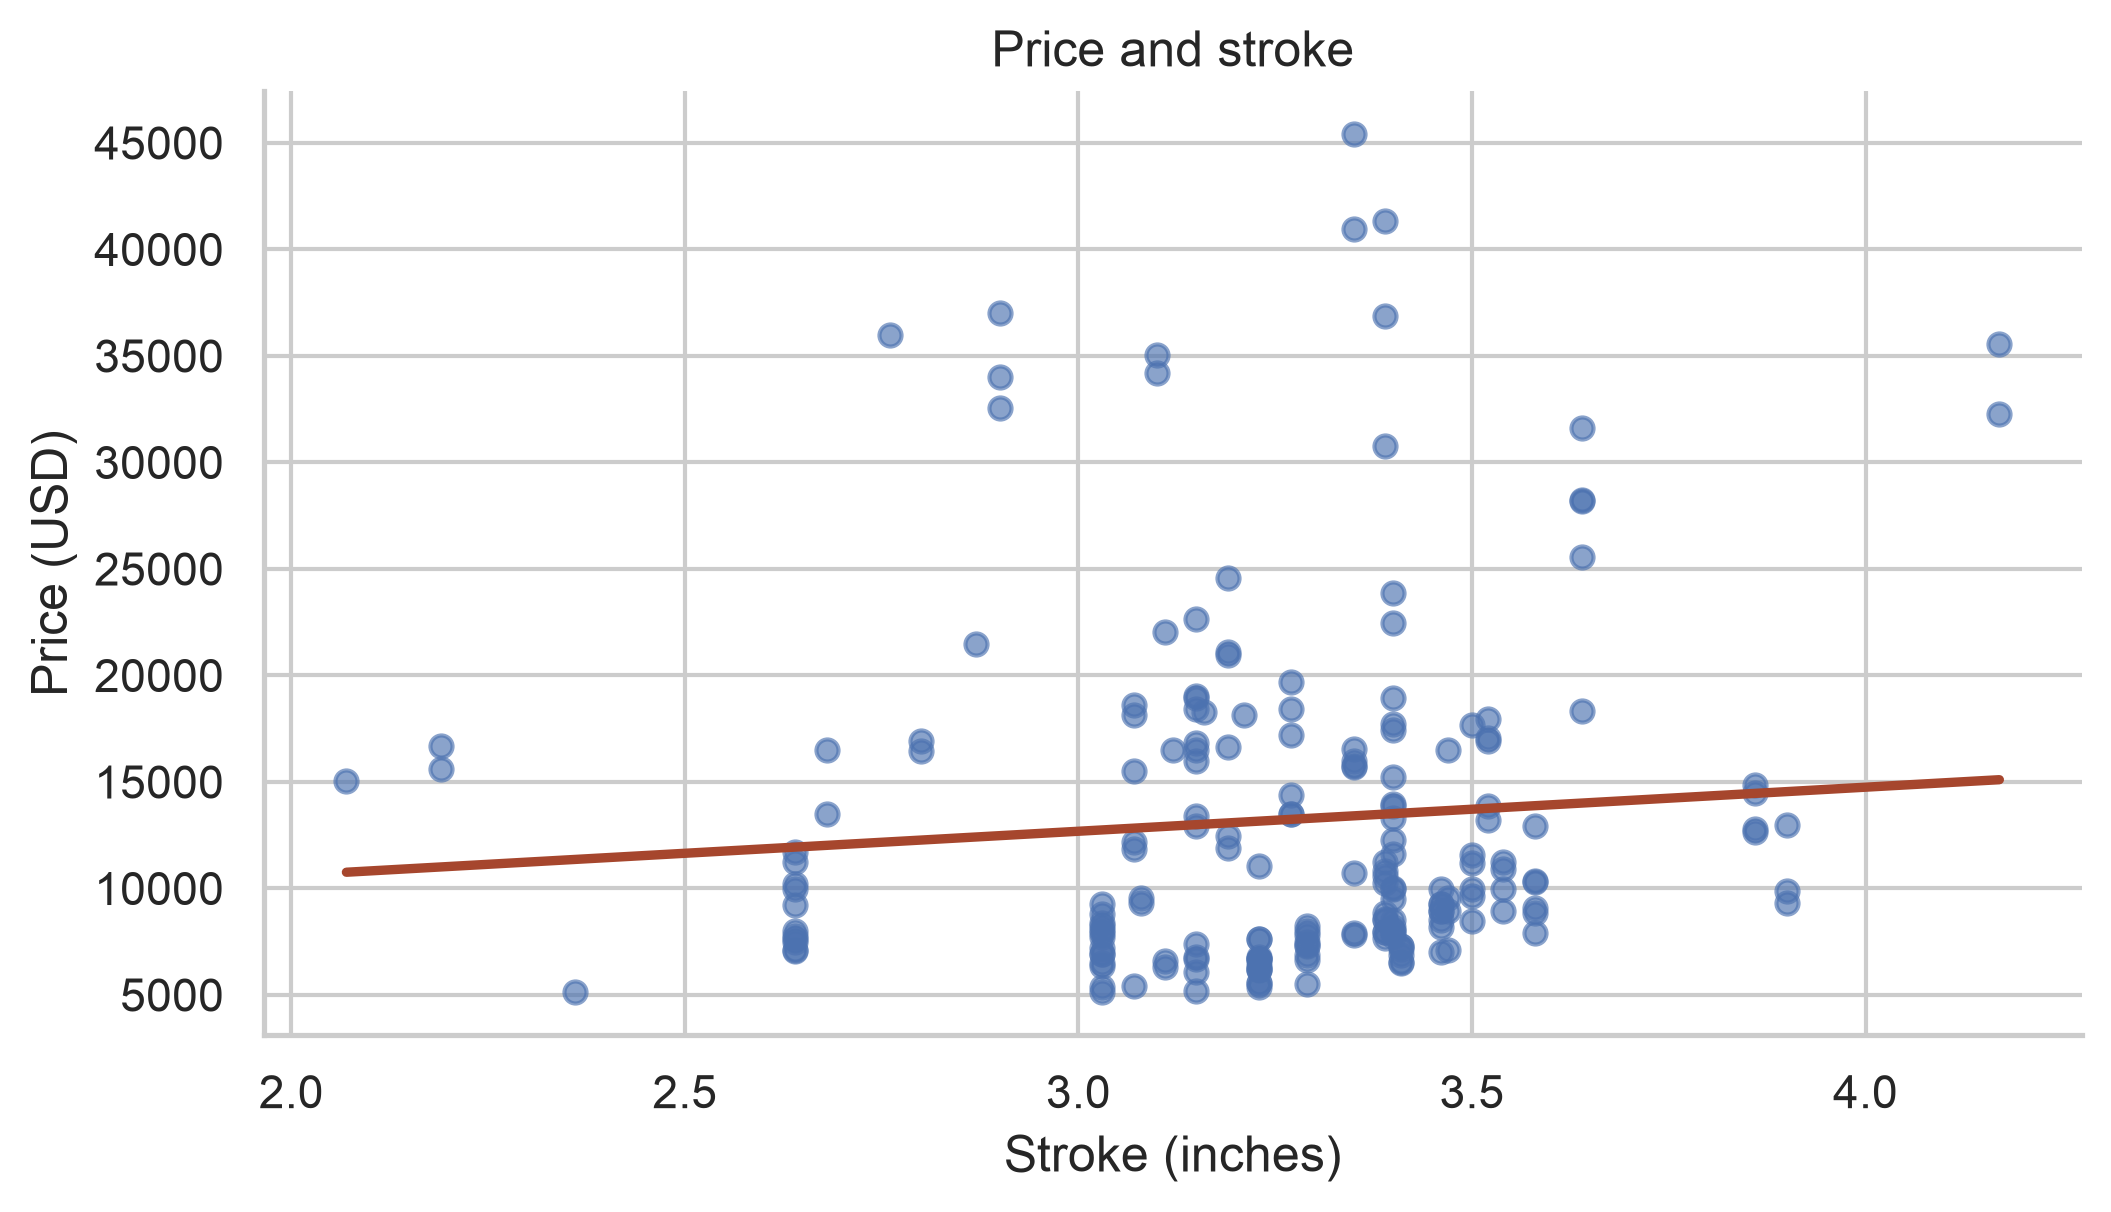

In [15]:
stroke_r = df['stroke'].corr(df['price'])
print(f'Stroke–price Pearson r = {stroke_r:.4f}; little marginal linear association is expected.')
fig, ax = plt.subplots()
sns.regplot(data=df, x='stroke', y='price', ci=None,
            scatter_kws={'alpha': 0.65, 's': 28}, line_kws={'color': '#a6462d'}, ax=ax)
ax.set(title='Price and stroke', xlabel='Stroke (inches)', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

The scattered prices and near-flat fitted trend agree with the small correlation. Stroke alone is unlikely to explain much linear price variation; that conclusion is narrower than saying stroke is irrelevant under every model.

<h3>Categorical Variables</h3>

<p>These are variables that describe a 'characteristic' of a data unit, and are selected from a small group of categories. The categorical variables can have the type "object" or "int64". A good way to visualize categorical variables is by using boxplots.</p>

Let's look at the relationship between "body-style" and "price".

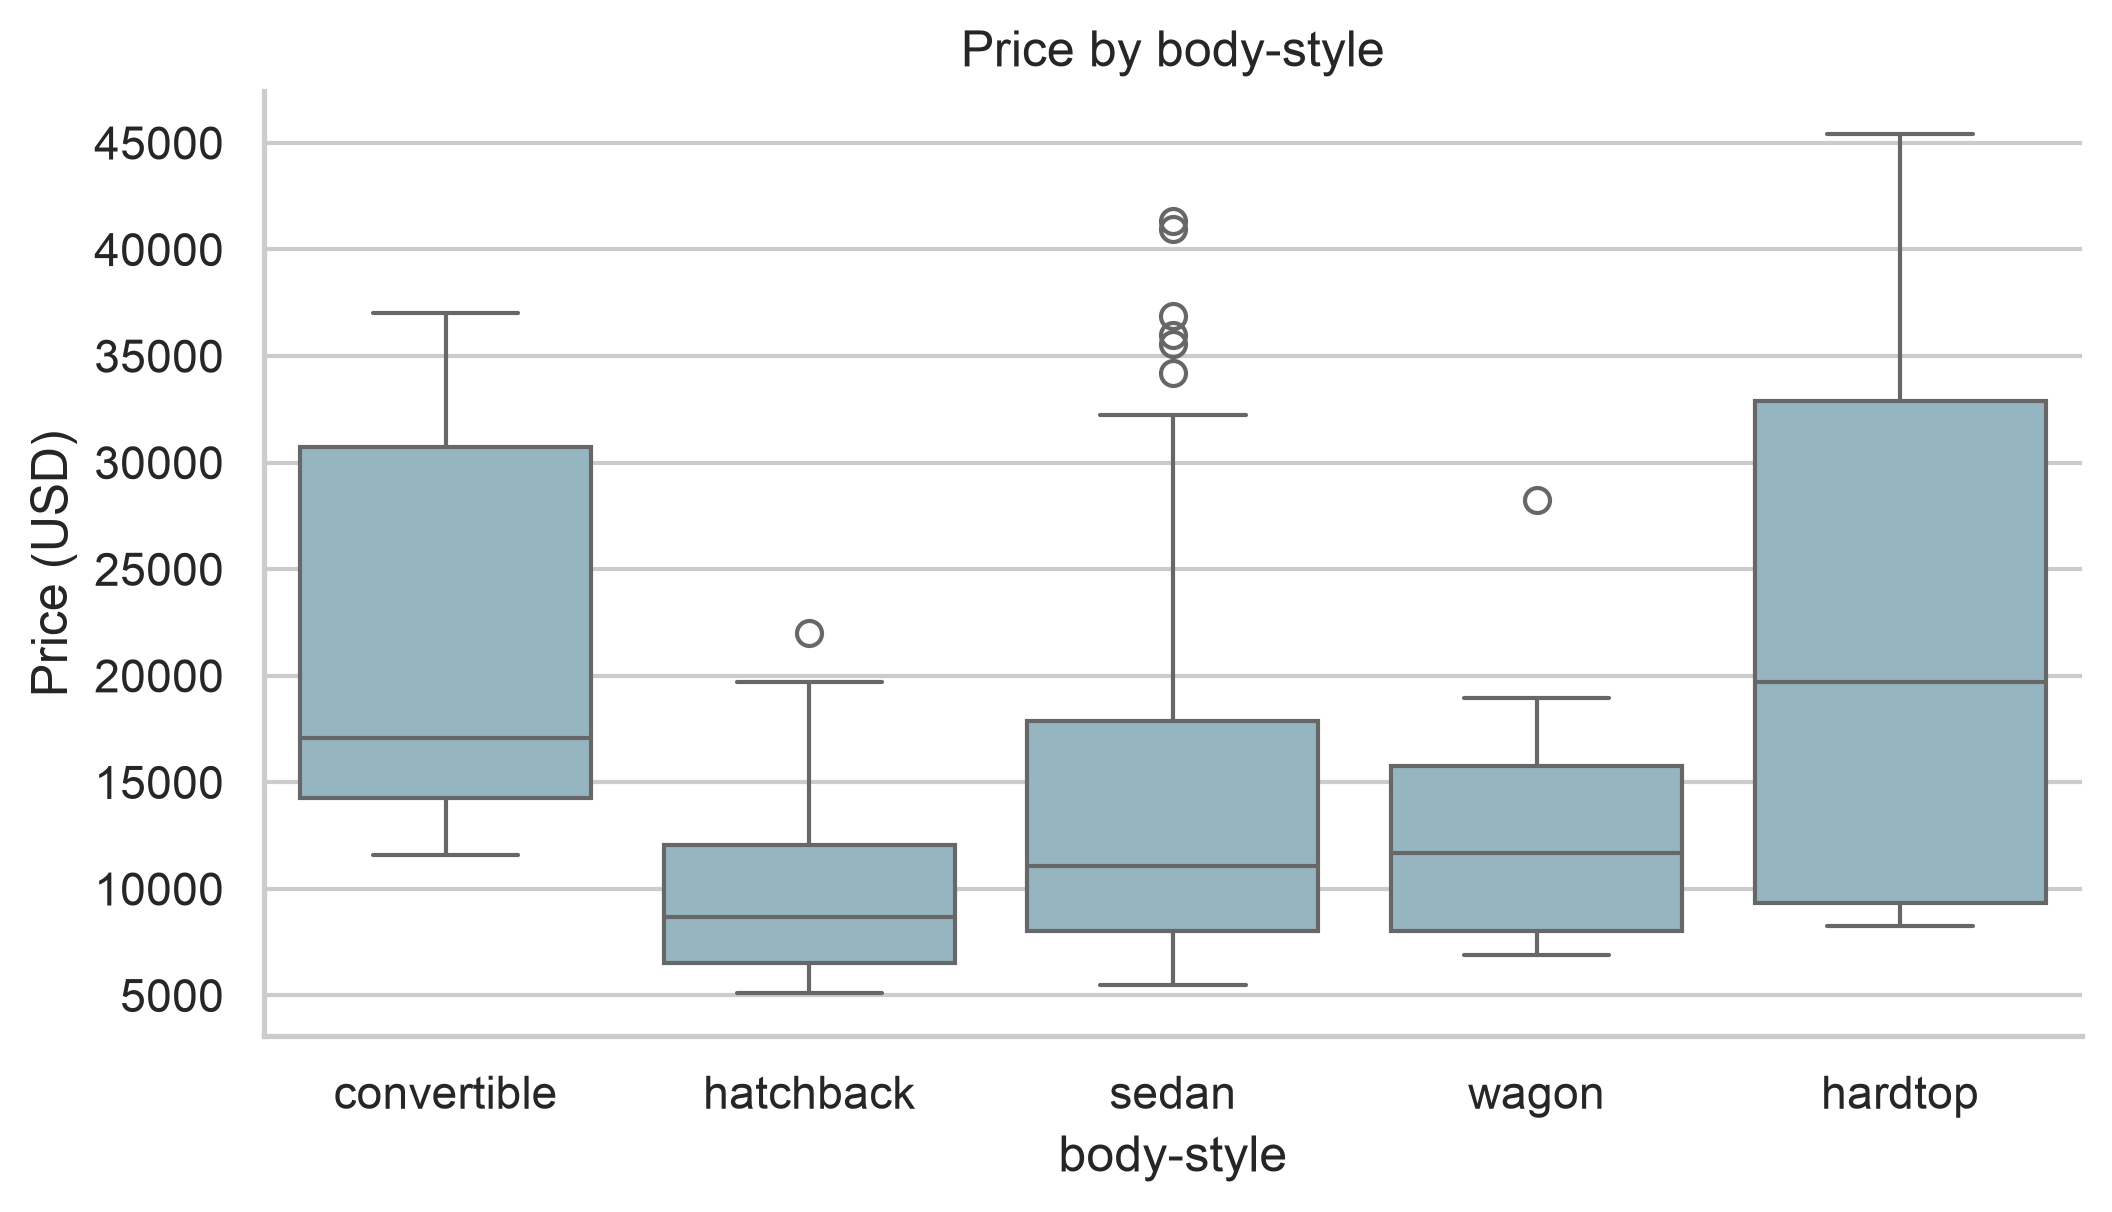

In [16]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='body-style', y='price', color='#8eb9c8', ax=ax)
ax.set(title='Price by body-style', xlabel='body-style', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

Body-style price distributions overlap substantially. This limits discrimination using body style alone, but does not establish that body style has no conditional predictive value. Next inspect engine location.

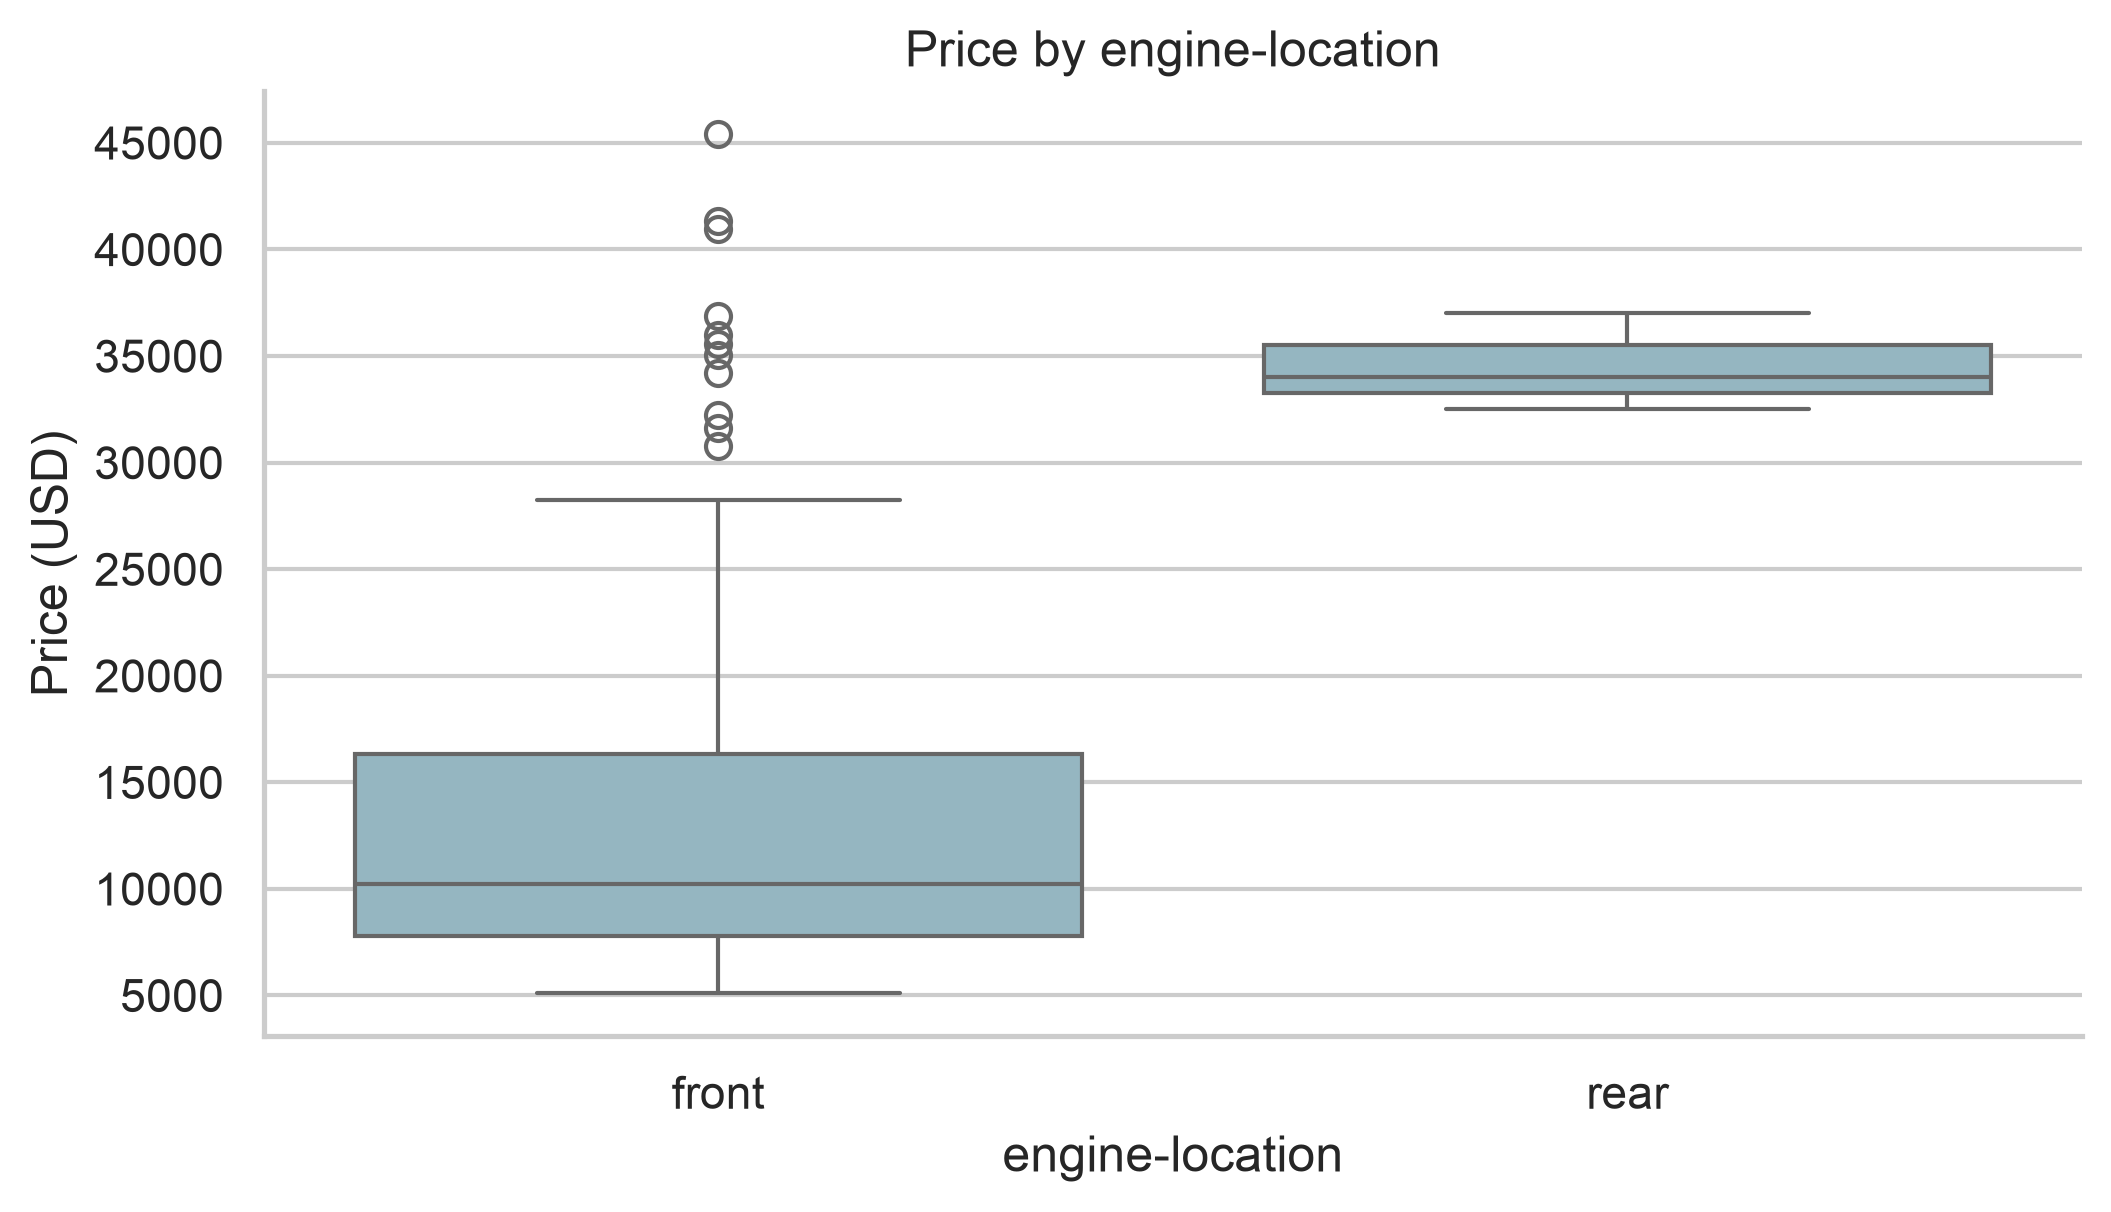

In [17]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='engine-location', y='price', color='#8eb9c8', ax=ax)
ax.set(title='Price by engine-location', xlabel='engine-location', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

Rear-engine cars have higher prices in this sample. The later count table is essential: very few rear-engine observations support this comparison.

Let's examine "drive-wheels" and "price".

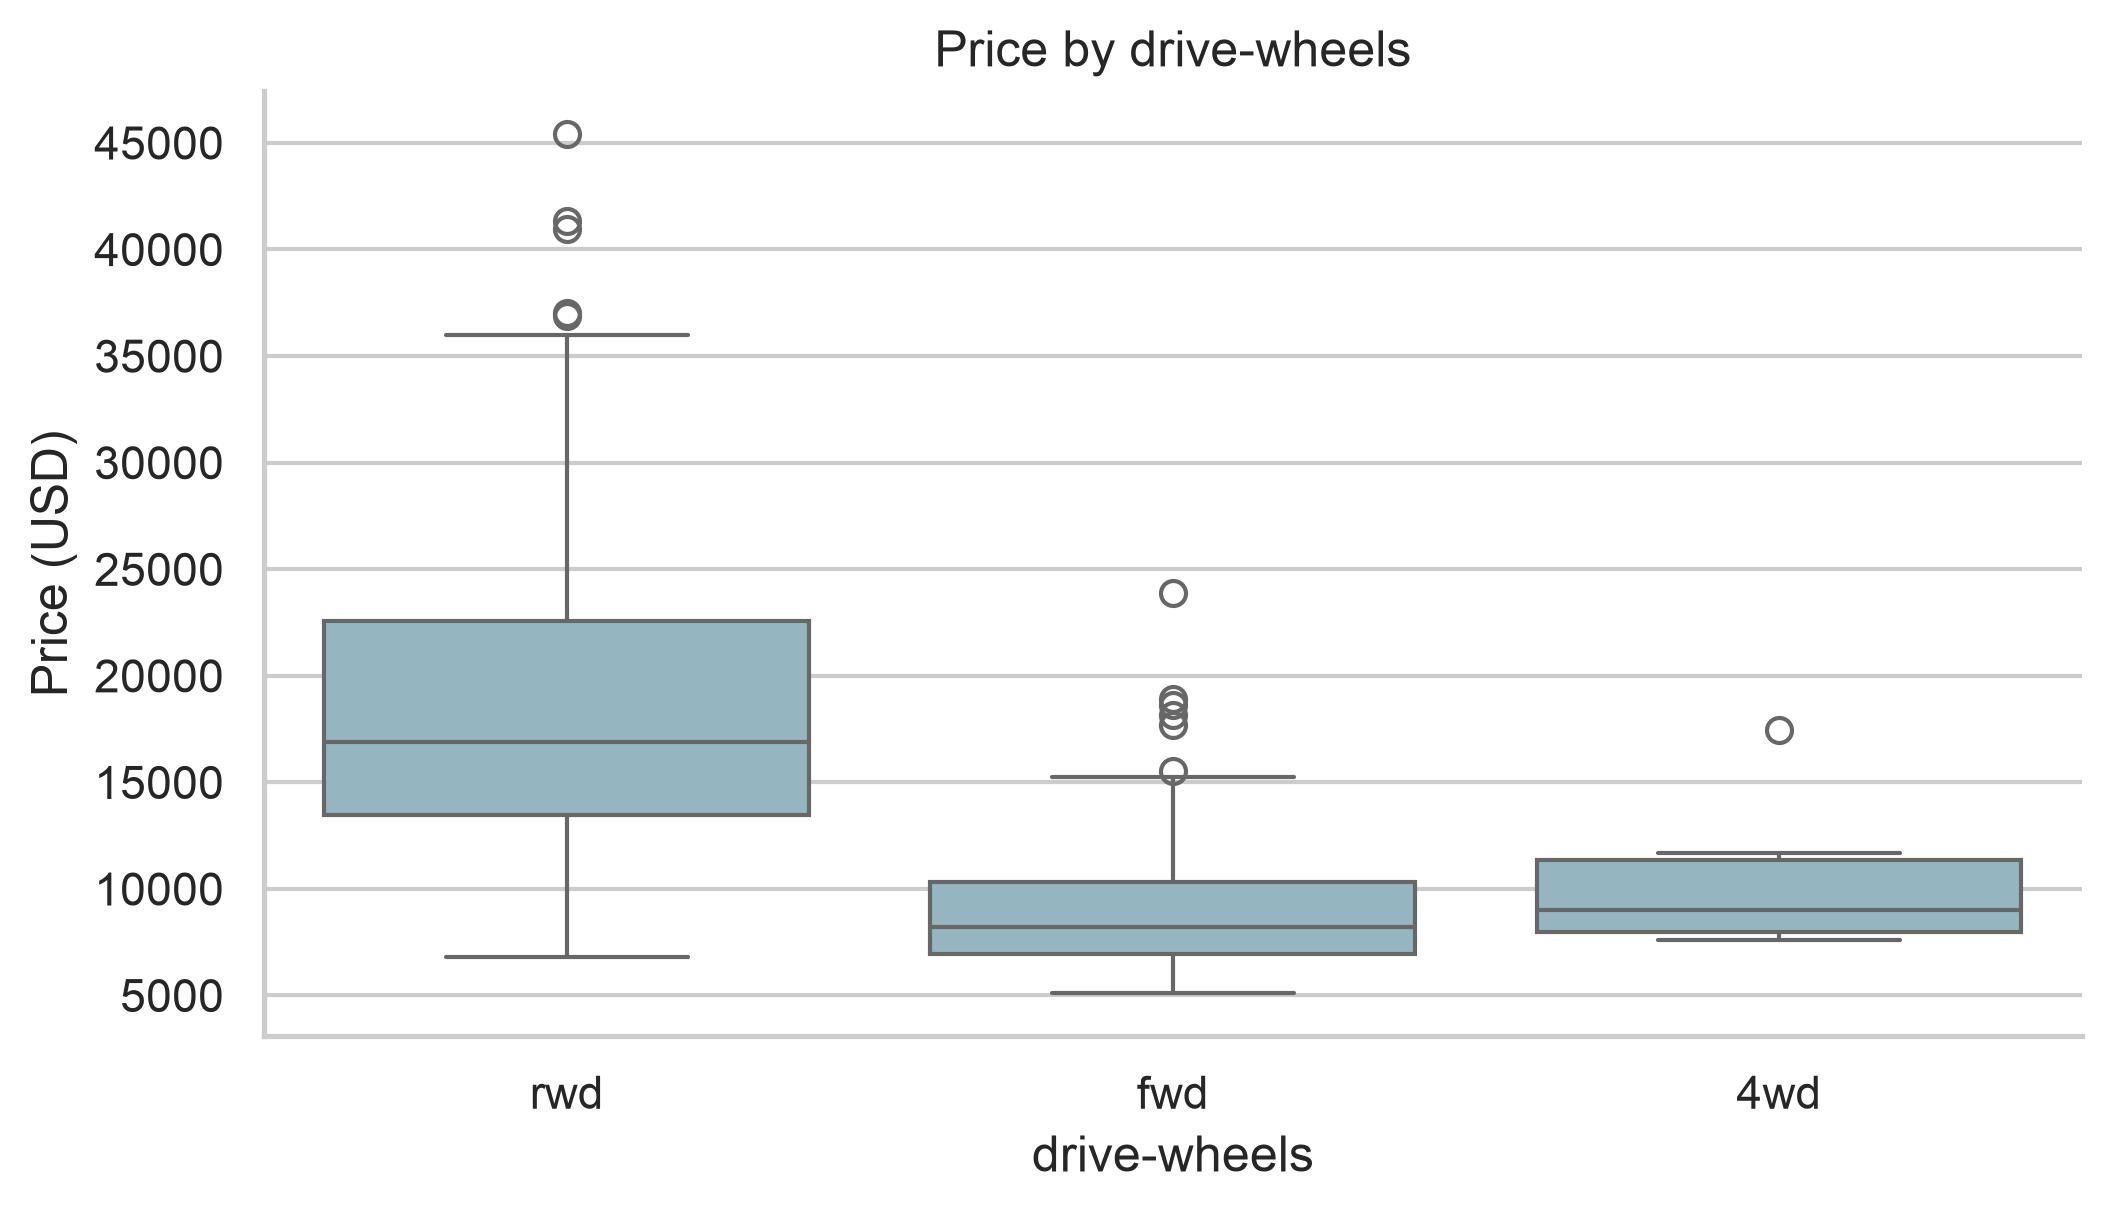

In [18]:
fig, ax = plt.subplots()
sns.boxplot(data=df, x='drive-wheels', y='price', color='#8eb9c8', ax=ax)
ax.set(title='Price by drive-wheels', xlabel='drive-wheels', ylabel='Price (USD)')
fig.tight_layout()
plt.show()

Rear-wheel-drive cars tend to be more expensive, although the distributions overlap. These groups may also differ in make, engine size and other attributes.

<h2 id="discriptive_statistics">3. Descriptive Statistical Analysis</h2>

The numerical summary includes count, mean, standard deviation, minimum, maximum, and the 25th, 50th and 75th percentiles. The interquartile range is the 75th percentile minus the 25th percentile; the 50th percentile is the median.

We can apply the method "describe" as follows:

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
symboling,201.0,0.8408,1.2548,-2.0000,0.0000,1.0000,2.0000,3.0000
normalized-losses,201.0,122.0000,31.9962,65.0000,101.0000,122.0000,137.0000,256.0000
wheel-base,201.0,98.7970,6.0664,86.6000,94.5000,97.0000,102.4000,120.9000
length,201.0,0.8371,0.0592,0.6780,0.8015,0.8323,0.8818,1.0000
width,201.0,0.9151,0.0292,0.8375,0.8903,0.9097,0.9250,1.0000
height,201.0,53.7667,2.4478,47.8000,52.0000,54.1000,55.5000,59.8000
curb-weight,201.0,2555.6667,517.2967,1488.0000,2169.0000,2414.0000,2926.0000,4066.0000
engine-size,201.0,126.8756,41.5468,61.0000,98.0000,120.0000,141.0000,326.0000
bore,201.0,3.3307,0.2681,2.5400,3.1500,3.3100,3.5800,3.9400
stroke,197.0,3.2569,0.3193,2.0700,3.1100,3.2900,3.4100,4.1700


Inspect text/categorical columns separately. Pandas 3 uses `str` for inferred text, so both `str` and `object` are included here.

In [20]:
df.select_dtypes(include=['object', 'str']).describe().T

,count,unique,top,freq
make,201,22,toyota,32
aspiration,201,2,std,165
num-of-doors,201,2,four,115
body-style,201,5,sedan,94
drive-wheels,201,3,fwd,118
engine-location,201,2,front,198
engine-type,201,6,ohc,145
num-of-cylinders,201,7,four,157
fuel-system,201,8,mpfi,92
horsepower-binned,200,3,Low,115


<h3>Value Counts</h3>

Use `Series.value_counts()` to count the categories in a single column, such as `df['drive-wheels']`. `DataFrame.value_counts()` is also available; it counts distinct combinations of values across the selected columns.

In [21]:
df['drive-wheels'].value_counts()

drive-wheels
fwd    118
rwd     75
4wd      8
Name: count, dtype: int64

We can convert the series to a dataframe as follows:

In [22]:
df['drive-wheels'].value_counts().to_frame(name='value_counts')

,value_counts
drive-wheels,
fwd,118
rwd,75
4wd,8


Store the frequency table with an explicit column name so the output is consistent across pandas versions.

In [23]:
drive_wheels_counts = df['drive-wheels'].value_counts().to_frame(name='value_counts')
drive_wheels_counts

,value_counts
drive-wheels,
fwd,118
rwd,75
4wd,8


Now let's rename the index to 'drive-wheels':

In [24]:
drive_wheels_counts.index.name = 'drive-wheels'
drive_wheels_counts

,value_counts
drive-wheels,
fwd,118
rwd,75
4wd,8


We can repeat the above process for the variable 'engine-location'.

In [25]:
engine_loc_counts = df['engine-location'].value_counts().to_frame(name='value_counts')
engine_loc_counts.index.name = 'engine-location'
engine_loc_counts

,value_counts
engine-location,
front,198
rear,3


Only three observations have rear engines. The observed difference is descriptive; the small group is too weak a basis for a broad claim about rear-engine vehicles.

<h2 id="basic_grouping">4. Basics of Grouping</h2>

<p>The "groupby" method groups data by different categories. The data is grouped based on one or several variables, and analysis is performed on the individual groups.</p>

<p>For example, let's group by the variable "drive-wheels". We see that there are 3 different categories of drive wheels.</p>

In [26]:
df['drive-wheels'].unique()

<ArrowStringArray>
['rwd', 'fwd', '4wd']
Length: 3, dtype: str

<p>If we want to know, on average, which type of drive wheel is most valuable, we can group "drive-wheels" and then average them.</p>

<p>We can select the columns 'drive-wheels', 'body-style' and 'price', then assign it to the variable "df_group_one".</p>

In [27]:
df_group_one = df[['drive-wheels','body-style','price']]

We can then calculate the average price for each of the different categories of data.

In [28]:
df_group_one = df_group_one.groupby('drive-wheels', as_index=False)['price'].mean()
df_group_one

,drive-wheels,price
0,4wd,10241.0000
1,fwd,9244.7797
2,rwd,19757.6133


<p>From our data, it seems rear-wheel drive vehicles are, on average, the most expensive, while 4-wheel and front-wheel are approximately the same in price.</p>

<p>You can also group by multiple variables. For example, let's group by both 'drive-wheels' and 'body-style'. This groups the dataframe by the unique combination of 'drive-wheels' and 'body-style'. We can store the results in the variable 'grouped_test1'.</p>

In [29]:
# grouping results
df_gptest = df[['drive-wheels','body-style','price']]
grouped_test1 = df_gptest.groupby(['drive-wheels','body-style'],as_index=False).mean()
grouped_test1

,drive-wheels,body-style,price
0,4wd,hatchback,7603.0000
1,4wd,sedan,12647.3333
2,4wd,wagon,9095.7500
3,fwd,convertible,11595.0000
4,fwd,hardtop,8249.0000
5,fwd,hatchback,8396.3878
6,fwd,sedan,9811.8000
7,fwd,wagon,9997.3333
8,rwd,convertible,23949.6000
9,rwd,hardtop,24202.7143


<p>This grouped data is much easier to visualize when it is made into a pivot table. A pivot table is like an Excel spreadsheet, with one variable along the column and another along the row. We can convert the dataframe to a pivot table using the method "pivot" to create a pivot table from the groups.</p>

<p>In this case, we will leave the drive-wheels variable as the rows of the table, and pivot body-style to become the columns of the table:</p>

In [30]:
grouped_pivot = grouped_test1.pivot(index='drive-wheels', columns='body-style', values='price')
grouped_pivot

body-style,convertible,hardtop,hatchback,sedan,wagon
drive-wheels,,,,,
4wd,NaN,NaN,7603.0000,12647.3333,9095.7500
fwd,11595.0,8249.0000,8396.3878,9811.8000,9997.3333
rwd,23949.6,24202.7143,14337.7778,21711.8333,16994.2222


An absent drive-wheel/body-style combination has no observed mean price. The template's zero-fill operation is shown separately for completeness; the analytical pivot and heatmaps keep those cells missing, rather than portray them as $0 cars.

In [31]:
zero_filled_example = grouped_pivot.fillna(0)
display(zero_filled_example)
print('Zeros above illustrate fillna only; missing combinations remain NaN in grouped_pivot.')

body-style,convertible,hardtop,hatchback,sedan,wagon
drive-wheels,,,,,
4wd,0.0,0.0000,7603.0000,12647.3333,9095.7500
fwd,11595.0,8249.0000,8396.3878,9811.8000,9997.3333
rwd,23949.6,24202.7143,14337.7778,21711.8333,16994.2222


Zeros above illustrate fillna only; missing combinations remain NaN in grouped_pivot.


<div class="alert alert-danger alertdanger" style="margin-top: 20px">
<h1>Question 4:</h1>

<p>Use the "groupby" function to find the average "price" of each car based on "body-style".</p>
</div>

In [32]:
grouped_test_bodystyle = df.groupby('body-style', as_index=False)['price'].mean()
display(grouped_test_bodystyle)
display(df.groupby('body-style')['price'].size().rename('Sample size').to_frame())

,body-style,price
0,convertible,21890.5000
1,hardtop,22208.5000
2,hatchback,9957.4412
3,sedan,14459.7553
4,wagon,12371.9600


,Sample size
body-style,
convertible,6
hardtop,8
hatchback,68
sedan,94
wagon,25


If you did not import "pyplot", let's do it again.

In [33]:
# The plotting imports were executed in the setup section.

<h4>Variables: Drive Wheels and Body Style vs. Price</h4>

Let's use a heat map to visualize the relationship between Body Style vs Price.

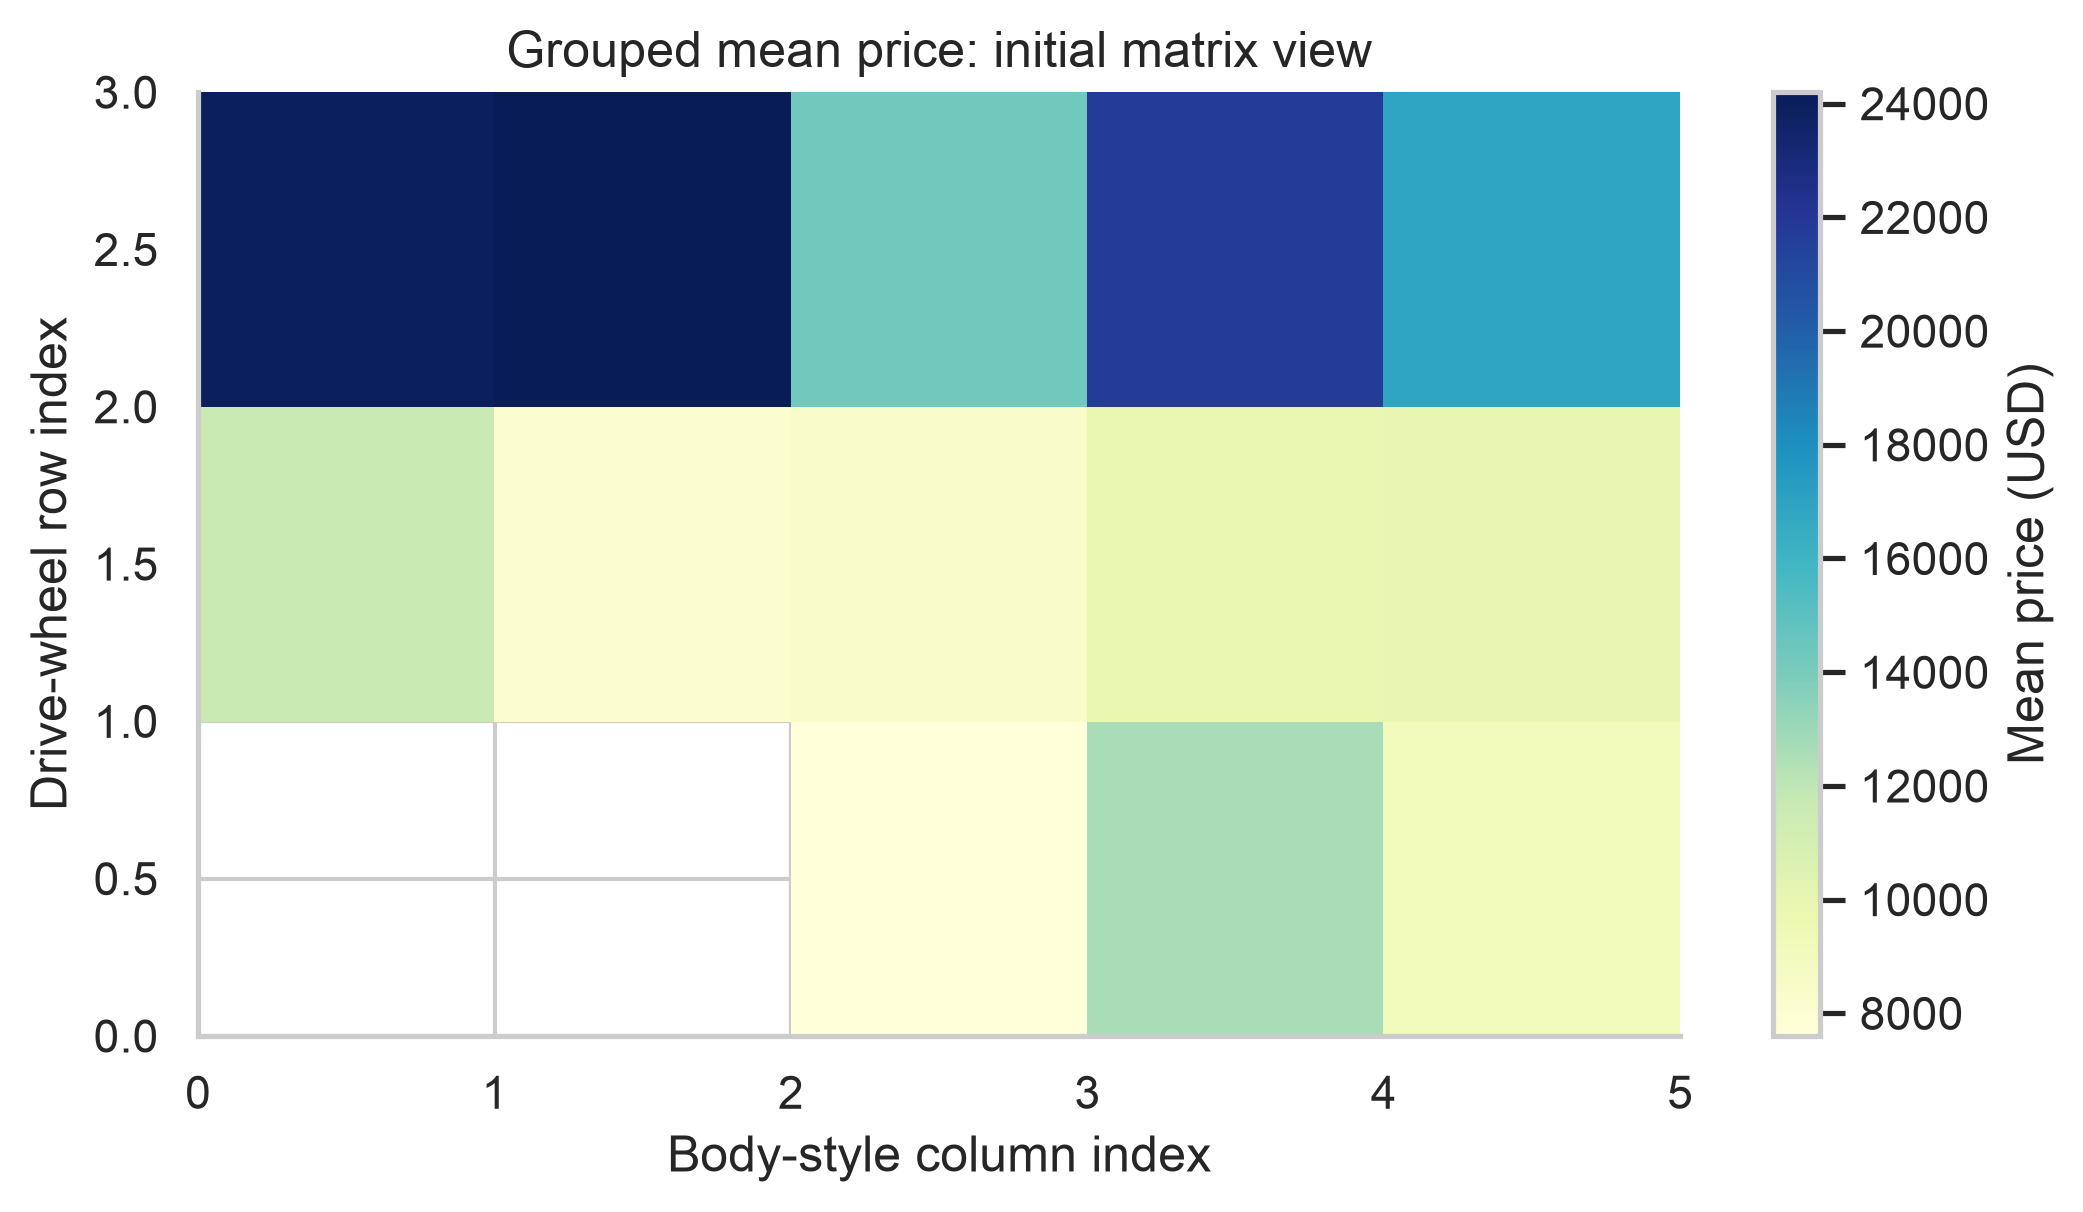

In [34]:
fig, ax = plt.subplots()
im = ax.pcolor(np.ma.masked_invalid(grouped_pivot.to_numpy()), cmap='YlGnBu')
fig.colorbar(im, ax=ax, label='Mean price (USD)')
ax.set(title='Grouped mean price: initial matrix view', xlabel='Body-style column index', ylabel='Drive-wheel row index')
fig.tight_layout()
plt.show()

<p>The heatmap plots the target variable (price) proportional to colour with respect to the variables 'drive-wheel' and 'body-style' on the vertical and horizontal axis, respectively. This allows us to visualize how the price is related to 'drive-wheel' and 'body-style'.</p>

<p>The default labels convey no useful information to us. Let's change that:</p>

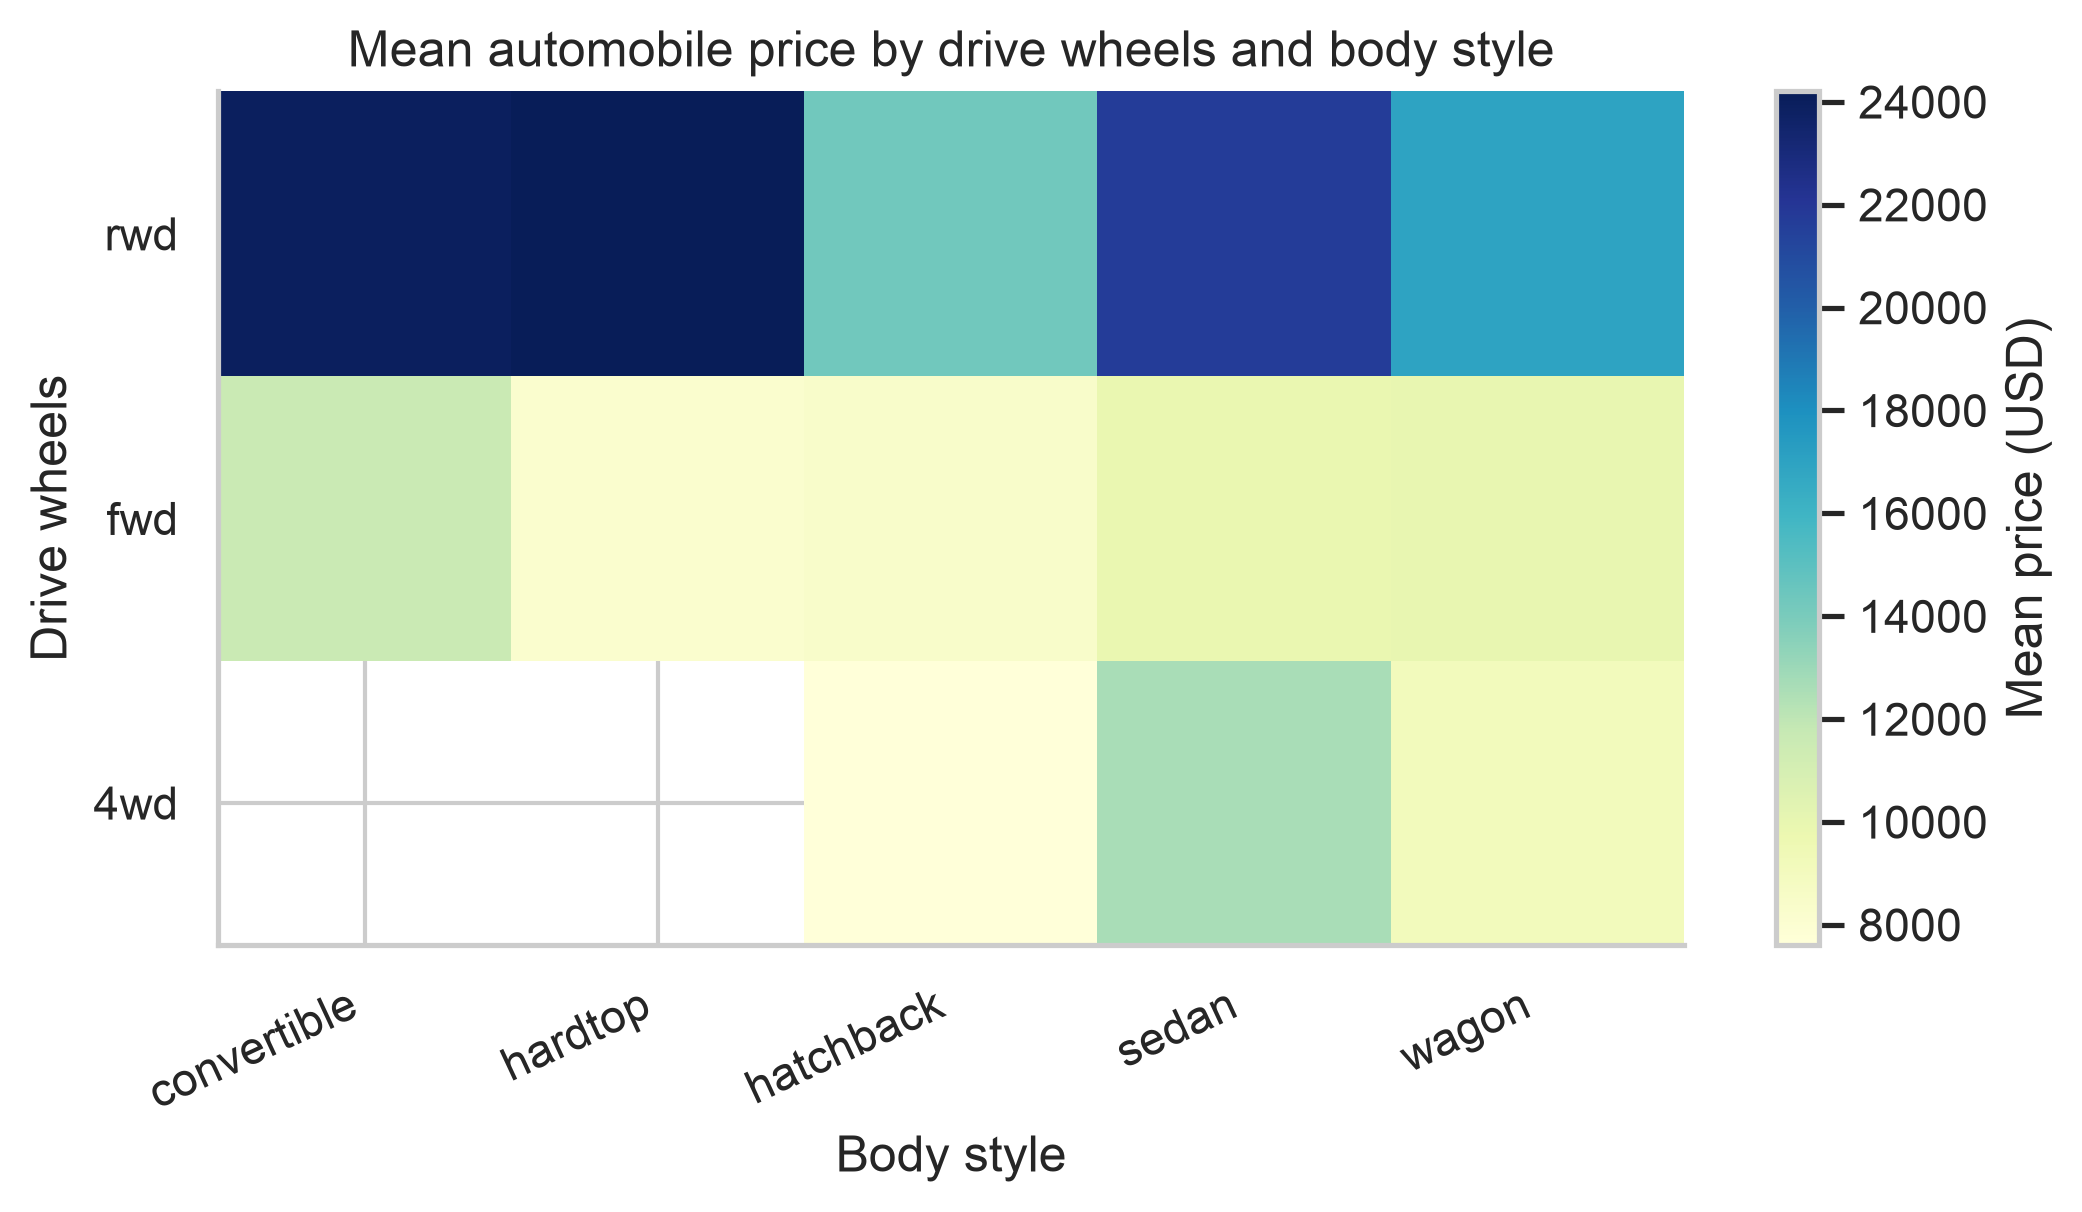

In [35]:
fig, ax = plt.subplots()
im = ax.pcolor(np.ma.masked_invalid(grouped_pivot.to_numpy()), cmap='YlGnBu')
ax.set_xticks(np.arange(grouped_pivot.shape[1]) + 0.5, labels=grouped_pivot.columns, rotation=25, ha='right')
ax.set_yticks(np.arange(grouped_pivot.shape[0]) + 0.5, labels=grouped_pivot.index)
ax.set(title='Mean automobile price by drive wheels and body style', xlabel='Body style', ylabel='Drive wheels')
fig.colorbar(im, ax=ax, label='Mean price (USD)')
fig.tight_layout()
plt.show()

Blank cells have no observations. Group means can be sensitive to small cell counts and expensive individual vehicles; the figure is a descriptive comparison, not a controlled estimate of body-style effects.

The grouped figures describe associations in this historical sample. Pearson correlations below provide another view of marginal linear relationships, not causal effects.

<h2 id="correlation_causation">5. Correlation and Causation</h2>

<p><b>Correlation</b>: a measure of the extent of interdependence between variables.</p>

<p><b>Causation</b>: the relationship between cause and effect between two variables.</p>

<p>It is important to know the difference between these two. Correlation does not imply causation. Determining correlation is much simpler  the determining causation as causation may require independent experimentation.</p>

**Pearson correlation** ranges from −1 to 1: −1 and 1 indicate exact decreasing and increasing linear relationships; 0 indicates no linear association. A coefficient of zero does not imply independence or exclude nonlinear relationships.

<p>Pearson Correlation is the default method of the function "corr". Like before, we can calculate the Pearson Correlation of the of the 'int64' or 'float64'  variables.</p>

In [36]:
df.select_dtypes(include='number').corr()

,symboling,normalized-losses,wheel-base,length,width,height,curb-weight,engine-size,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price,city-L/100km,diesel,gas
symboling,1.0000,0.4663,-0.5360,-0.3654,-0.2424,-0.5502,-0.2331,-0.1106,-0.1400,-0.0082,-0.1822,0.0758,0.2797,-0.0355,0.0362,-0.0824,0.0662,-0.1967,0.1967
normalized-losses,0.4663,1.0000,-0.0567,0.0194,0.0868,-0.3737,0.0994,0.1124,-0.0299,0.0556,-0.1147,0.2173,0.2395,-0.2250,-0.1819,0.1340,0.2386,-0.1015,0.1015
wheel-base,-0.5360,-0.0567,1.0000,0.8760,0.8145,0.5907,0.7821,0.5720,0.4932,0.1585,0.2503,0.3711,-0.3603,-0.4706,-0.5433,0.5846,0.4762,0.3072,-0.3072
length,-0.3654,0.0194,0.8760,1.0000,0.8572,0.4921,0.8807,0.6850,0.6090,0.1241,0.1597,0.5798,-0.2860,-0.6652,-0.6981,0.6906,0.6574,0.2112,-0.2112
width,-0.2424,0.0868,0.8145,0.8572,1.0000,0.3060,0.8662,0.7294,0.5449,0.1888,0.1899,0.6151,-0.2458,-0.6335,-0.6806,0.7513,0.6734,0.2444,-0.2444
height,-0.5502,-0.3737,0.5907,0.4921,0.3060,1.0000,0.3076,0.0747,0.1804,-0.0627,0.2597,-0.0870,-0.3100,-0.0498,-0.1048,0.1355,0.0038,0.2816,-0.2816
curb-weight,-0.2331,0.0994,0.7821,0.8807,0.8662,0.3076,1.0000,0.8491,0.6441,0.1676,0.1564,0.7580,-0.2794,-0.7495,-0.7949,0.8344,0.7854,0.2210,-0.2210
engine-size,-0.1106,0.1124,0.5720,0.6850,0.7294,0.0747,0.8491,1.0000,0.5726,0.2095,0.0289,0.8227,-0.2567,-0.6505,-0.6796,0.8723,0.7451,0.0708,-0.0708
bore,-0.1400,-0.0299,0.4932,0.6090,0.5449,0.1804,0.6441,0.5726,1.0000,-0.0554,0.0013,0.5669,-0.2674,-0.5820,-0.5913,0.5432,0.5546,0.0545,-0.0545
stroke,-0.0082,0.0556,0.1585,0.1241,0.1888,-0.0627,0.1676,0.2095,-0.0554,1.0000,0.1879,0.0985,-0.0657,-0.0347,-0.0352,0.0823,0.0373,0.2413,-0.2413


Sometimes we would like to know the significant of the correlation estimate.

**P-value.** Under the null hypothesis of zero population correlation and the test's assumptions, this is the probability of a statistic at least as extreme as the observed one. It is not the probability that the null is true or that a finding is important. Report the coefficient alongside the p-value; the nine comparisons are exploratory and no multiple-testing adjustment is applied.

We can obtain this information using  "stats" module in the "scipy"  library.

In [37]:
from scipy import stats

<h3>Wheel-Base vs. Price</h3>

Let's calculate the  Pearson Correlation Coefficient and P-value of 'wheel-base' and 'price'.

In [38]:
pair = df[['wheel-base', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['wheel-base'], pair['price'])
print(f'wheel-base: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

wheel-base: r = 0.584642, p = 8.076e-20, n = 201


<h3>Horsepower vs. Price</h3>

Let's calculate the  Pearson Correlation Coefficient and P-value of 'horsepower' and 'price'.

In [39]:
pair = df[['horsepower', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['horsepower'], pair['price'])
print(f'horsepower: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

horsepower: r = 0.809575, p = 6.369e-48, n = 201


<h3>Length vs. Price</h3>

Let's calculate the  Pearson Correlation Coefficient and P-value of 'length' and 'price'.

In [40]:
pair = df[['length', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['length'], pair['price'])
print(f'length: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

length: r = 0.690628, p = 8.016e-30, n = 201


<h3>Width vs. Price</h3>

Let's calculate the Pearson Correlation Coefficient and P-value of 'width' and 'price':

In [41]:
pair = df[['width', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['width'], pair['price'])
print(f'width: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

width: r = 0.751265, p = 9.200e-38, n = 201


### Curb-Weight vs. Price

Let's calculate the Pearson Correlation Coefficient and P-value of 'curb-weight' and 'price':

In [42]:
pair = df[['curb-weight', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['curb-weight'], pair['price'])
print(f'curb-weight: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

curb-weight: r = 0.834415, p = 2.190e-53, n = 201


<h3>Engine-Size vs. Price</h3>

Let's calculate the Pearson Correlation Coefficient and P-value of 'engine-size' and 'price':

In [43]:
pair = df[['engine-size', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['engine-size'], pair['price'])
print(f'engine-size: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

engine-size: r = 0.872335, p = 9.265e-64, n = 201


<h3>Bore vs. Price</h3>

Let's calculate the  Pearson Correlation Coefficient and P-value of 'bore' and 'price':

In [44]:
pair = df[['bore', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['bore'], pair['price'])
print(f'bore: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

bore: r = 0.543155, p = 8.049e-17, n = 201


We can relate the process for each 'city-mpg'  and 'highway-mpg':

<h3>City-mpg vs. Price</h3>

In [45]:
pair = df[['city-mpg', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['city-mpg'], pair['price'])
print(f'city-mpg: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

city-mpg: r = -0.686571, p = 2.321e-29, n = 201


<h3>Highway-mpg vs. Price</h3>

In [46]:
pair = df[['highway-mpg', 'price']].dropna()
pearson_coef, p_value = stats.pearsonr(pair['highway-mpg'], pair['price'])
print(f'highway-mpg: r = {pearson_coef:.6f}, p = {p_value:.3e}, n = {len(pair)}')

highway-mpg: r = -0.704692, p = 1.750e-31, n = 201


In [47]:
pearson_rows = []
for feature in ['wheel-base', 'horsepower', 'length', 'width', 'curb-weight', 'engine-size', 'bore', 'city-mpg', 'highway-mpg']:
    pair = df[[feature, 'price']].dropna()
    r, p = stats.pearsonr(pair[feature], pair['price'])
    pearson_rows.append({'Feature': feature, 'n': len(pair), 'Pearson r': r, 'p-value': p})
pearson_summary = pd.DataFrame(pearson_rows).set_index('Feature')
display(pearson_summary.style.format({'Pearson r': '{:.4f}', 'p-value': '{:.3e}'}))

,n,Pearson r,p-value
Feature,,,
wheel-base,201,0.5846,8.076e-20
horsepower,201,0.8096,6.369e-48
length,201,0.6906,8.016e-30
width,201,0.7513,9.200e-38
curb-weight,201,0.8344,2.190e-53
engine-size,201,0.8723,9.265e-64
bore,201,0.5432,8.049e-17
city-mpg,201,-0.6866,2.321e-29
highway-mpg,201,-0.7047,1.750e-31


<h3>Conclusion: Important Variables</h3>

Engine size, curb weight and horsepower show strong marginal positive associations with price, while fuel economy has a negative association. Length, width, wheel base and bore are also candidates for the next module. Several of these measurements describe related aspects of vehicle size, so they may overlap in a multivariable model. Drive-wheel groups differ descriptively. These EDA results motivate validation; they do not establish causal effects or out-of-sample accuracy.

## Author

<a href="https://www.linkedin.com/in/joseph-s-50398b136/" target="_blank">Joseph Santarcangelo</a>


### Other Contributors

<a href="https://www.linkedin.com/in/mahdi-noorian-58219234/" target="_blank">Mahdi Noorian PhD</a>

Bahare Talayian

Eric Xiao

Steven Dong

Parizad

Hima Vasudevan

<a href="https://www.linkedin.com/in/fiorellawever/" target="_blank">Fiorella Wenver</a>

<a href=" https://www.linkedin.com/in/yi-leng-yao-84451275/ " target="_blank" >Yi Yao</a>.

<a href="https://www.coursera.org/instructor/~129186572/" target="_blank" >Abhishek Gagneja </a>

## Change Log


|  Date (YYYY-MM-DD) |  Version | Changed By  |  Change Description |
|---|---|---|---|
| 2023-09-28 | 2.2 | Abhishek Gagneja | Updated instructions |
| 2020-10-30  | 2.1  | Lakshmi |  changed URL of csv  |
| 2020-08-27  | 2.0  | Lavanya  |  Moved lab to course repo in GitLab  |



<hr>

## <h3 align="center"> © IBM Corporation 2023. All rights reserved. <h3/>

## Tool acknowledgement

OpenAI Codex assisted with code completion, debugging and explanation drafting. Numerical results and figures were generated by executing the notebook in the recorded local Python environment. The collaborators are responsible for reviewing the analysis and submitted material. [OpenAI Codex](https://openai.com/codex/) (accessed 15 September 2026).